# Submission 2 &ndash; Intermediate Submission

## Instructions

- Fill out the *Basic Information* and the *Results* sections.
- Make sure that this `.ipynb` file displays correctly in the GitHub file preview, including any visual output.
- If you find that any output does not display correctly, include a static screenshot as an image. For interactive outputs, add a link to a short screencast located in your repository.
- Push all required files before the deadline.

---
## Basic Information

**Team Name:** Bounty Hunters

**Team Members:**
- Waji Ul Hassan Syed, syedwajiulhassan715-rgb
- Saqib Ali Khan, saqib00987 
- Syed Raffey Uz Zaman, Unfortunate0-Hero
- TODO (Full Name, GitHub username)

**Dataset Description:**  
(max. 75 words; this serves just as a reminder)

The FRED Macroeconomic Bundle combines eight U.S. economic time series 
from the Federal Reserve Bank of St. Louis (2000–2026): Federal Funds 
Rate, 2- and 10-year Treasury yields, CPI, unemployment rate, S&P 500, 
30-year mortgage rate, and consumer sentiment. Resampled to monthly 
frequency and merged into ~310 rows. Covers major events including the 
2008 financial crisis, 2020 COVID shock, and 2022 inflation spike.

---

## Code

Here you may place any code that is not an immediate part of your submission. Only the content of the *Results* sections will be graded for this submission.

## Imports
We import the libraries needed for data loading, wrangling, and visualization.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from io import StringIO

## Data Loading

We download all 8 FRED series using their public CSV API. FRED uses `"."` as a missing value marker which we convert to `NaN`. Each series is stored in a dictionary keyed by its series ID.

In [17]:
BASE_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id="

SERIES = {
    "FEDFUNDS":     "Effective Federal Funds Rate (%)",
    "DGS10":        "10-Year Treasury Yield (%)",
    "DGS2":         "2-Year Treasury Yield (%)",
    "CPIAUCSL":     "Consumer Price Index",
    "UNRATE":       "Unemployment Rate (%)",
    "SP500":        "S&P 500 Index",
    "MORTGAGE30US": "30-Year Mortgage Rate (%)",
    "UMCSENT":      "Consumer Sentiment",
}

def fetch_fred(series_id):
    url = BASE_URL + series_id
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("observation_date")
    df.index.name = "DATE"
    df.columns = [series_id]
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df[series_id]

# Download all series
raw = {}
for sid in SERIES:
    print(f"Downloading {sid}...")
    raw[sid] = fetch_fred(sid)

print("\nAll series downloaded successfully.")


All series downloaded successfully.


## Resampling to Monthly Frequency

The series have different frequencies — daily (DGS10, DGS2, SP500), weekly (MORTGAGE30US), and monthly (FEDFUNDS, CPIAUCSL, UNRATE, UMCSENT). We resample all of them to month-end frequency by taking the last available value of each month so they can be merged into one unified DataFrame.

In [18]:
# Daily series → last value of each month
dgs10_m  = raw["DGS10"].resample("ME").last()
dgs2_m   = raw["DGS2"].resample("ME").last()
sp500_m  = raw["SP500"].resample("ME").last()

# Weekly series → last value of each month
mort_m   = raw["MORTGAGE30US"].resample("ME").last()

# Monthly series → align to month-end index
fedfunds_m = raw["FEDFUNDS"].resample("ME").last()
cpi_m      = raw["CPIAUCSL"].resample("ME").last()
unrate_m   = raw["UNRATE"].resample("ME").last()
umcsent_m  = raw["UMCSENT"].resample("ME").last()

print("Resampling complete.")

Resampling complete.


## Merging into one DataFrame

We merge all 8 resampled series into a single DataFrame and filter to keep only data from January 2000 onward, covering the period of interest which includes the 2008 financial crisis, 2020 COVID shock, and 2022 inflation spike.

In [19]:
df = pd.DataFrame({
    "FEDFUNDS":     fedfunds_m,
    "DGS10":        dgs10_m,
    "DGS2":         dgs2_m,
    "CPIAUCSL":     cpi_m,
    "UNRATE":       unrate_m,
    "SP500":        sp500_m,
    "MORTGAGE30US": mort_m,
    "UMCSENT":      umcsent_m,
})

# Keep only from January 2000 onward
df = df[df.index >= "2000-01-01"]

print(f"Shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
df.head()

Shape: (317, 8)

Missing values per column:
FEDFUNDS          1
DGS10             0
DGS2              0
CPIAUCSL          3
UNRATE            2
SP500           196
MORTGAGE30US      0
UMCSENT           2
dtype: int64


,FEDFUNDS,DGS10,DGS2,CPIAUCSL,UNRATE,SP500,MORTGAGE30US,UMCSENT
DATE,,,,,,,,
2000-01-31,5.45,6.68,6.61,169.3,4.0,NaN,8.25,112.0
2000-02-29,5.73,6.42,6.53,170.0,4.1,NaN,8.31,111.3
2000-03-31,5.85,6.03,6.50,171.0,4.0,NaN,8.23,107.1
2000-04-30,6.02,6.23,6.68,170.9,3.8,NaN,8.13,109.2
2000-05-31,6.27,6.29,6.69,171.2,4.0,NaN,8.62,110.7


## Handling Missing Values

We use forward-fill to propagate the last known value forward for small gaps, followed by backward-fill to handle any leading NaN values at the start of the series.

In [20]:
df = df.ffill().bfill()

print("Missing values after fill:")
print(df.isnull().sum())

Missing values after fill:
FEDFUNDS        0
DGS10           0
DGS2            0
CPIAUCSL        0
UNRATE          0
SP500           0
MORTGAGE30US    0
UMCSENT         0
dtype: int64


## Computing Derived Columns

We compute two derived columns needed for our hypotheses:
- **SPREAD**: the yield curve spread (10-year minus 2-year Treasury yield). When this goes negative the yield curve is inverted, historically a recession warning signal.
- **INFLATION_YOY**: year-over-year percentage change in CPI, which is a more meaningful measure of inflation than raw CPI levels.

We also define the official NBER recession periods within our 2000–2026 window, which will be used to shade recession bands in our visualizations.

In [21]:
# Yield curve spread (core variable for A.2)
df["SPREAD"] = df["DGS10"] - df["DGS2"]

# Year-over-year inflation
df["INFLATION_YOY"] = df["CPIAUCSL"].pct_change(12) * 100

# NBER recession periods within our window
# Source: https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions
RECESSIONS = [
    ("2001-03-01", "2001-11-01"),  # Dot-com bust
    ("2007-12-01", "2009-06-01"),  # Great Financial Crisis
    ("2020-02-01", "2020-04-01"),  # COVID-19
]

print("Derived columns added.")
print(f"\nFinal dataset shape: {df.shape}")
print(f"\nColumn list: {list(df.columns)}")
df.head()

Derived columns added.

Final dataset shape: (317, 10)

Column list: ['FEDFUNDS', 'DGS10', 'DGS2', 'CPIAUCSL', 'UNRATE', 'SP500', 'MORTGAGE30US', 'UMCSENT', 'SPREAD', 'INFLATION_YOY']


,FEDFUNDS,DGS10,DGS2,CPIAUCSL,UNRATE,SP500,MORTGAGE30US,UMCSENT,SPREAD,INFLATION_YOY
DATE,,,,,,,,,,
2000-01-31,5.45,6.68,6.61,169.3,4.0,2096.96,8.25,112.0,0.07,NaN
2000-02-29,5.73,6.42,6.53,170.0,4.1,2096.96,8.31,111.3,-0.11,NaN
2000-03-31,5.85,6.03,6.50,171.0,4.0,2096.96,8.23,107.1,-0.47,NaN
2000-04-30,6.02,6.23,6.68,170.9,3.8,2096.96,8.13,109.2,-0.45,NaN
2000-05-31,6.27,6.29,6.69,171.2,4.0,2096.96,8.62,110.7,-0.40,NaN


## Visualization A.1 — Fed Funds Rate vs Unemployment Rate

Dual-axis time series chart overlaying FEDFUNDS and UNRATE with recession bands shaded. Defined as a function so it can be called cleanly in the Results section.

In [30]:
def plot_a1():
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # ── Recession shading ──────────────────────────────────────
    recession_patch = None
    for start, end in RECESSIONS:
        recession_patch = ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    color="lightgrey", alpha=0.5)

    # ── Left axis: Federal Funds Rate ─────────────────────────
    color_fed = "#1f77b4"
    ax1.set_xlabel("Year", fontsize=12)
    ax1.set_ylabel("Federal Funds Rate (%)", color=color_fed, fontsize=12)
    ax1.plot(df.index, df["FEDFUNDS"], color=color_fed,
             linewidth=2, label="Federal Funds Rate")
    ax1.tick_params(axis="y", labelcolor=color_fed)
    ax1.set_ylim(0, 16)

    # ── Right axis: Unemployment Rate ─────────────────────────
    ax2 = ax1.twinx()
    color_unem = "#d62728"
    ax2.set_ylabel("Unemployment Rate (%)", color=color_unem, fontsize=12)
    ax2.plot(df.index, df["UNRATE"], color=color_unem,
             linewidth=2, label="Unemployment Rate")
    ax2.tick_params(axis="y", labelcolor=color_unem)
    ax2.set_ylim(0, 16)

    # ── Find rate peaks programmatically per cycle ─────────────
    cycle1_fed = df.loc["1999-01-01":"2001-06-01", "FEDFUNDS"]
    peak1_fed  = cycle1_fed.idxmax()

    cycle2_fed = df.loc["2004-01-01":"2007-06-01", "FEDFUNDS"]
    peak2_fed  = cycle2_fed.idxmax()

    cycle3_fed = df.loc["2022-01-01":"2024-06-01", "FEDFUNDS"]
    peak3_fed  = cycle3_fed.idxmax()

    # ── Find unemployment peaks per cycle ─────────────────────
    cycle1_unem = df.loc["2001-01-01":"2004-06-01", "UNRATE"]
    peak1_unem  = cycle1_unem.idxmax()

    cycle2_unem = df.loc["2008-01-01":"2011-06-01", "UNRATE"]
    peak2_unem  = cycle2_unem.idxmax()

    # ── Draw rate peak lines ───────────────────────────────────
    rate_peaks = [
        (peak1_fed, f"Rate Peak\n({peak1_fed.strftime('%b %Y')})"),
        (peak2_fed, f"Rate Peak\n({peak2_fed.strftime('%b %Y')})"),
        (peak3_fed, f"Rate Peak\n({peak3_fed.strftime('%b %Y')})"),
    ]
    for peak_date, label in rate_peaks:
        ax1.axvline(peak_date, color=color_fed,
                    linestyle="--", linewidth=1.5, alpha=0.7)
        ax1.text(peak_date, 15.2, label,
                 color=color_fed, fontsize=8,
                 ha="center", va="top")

    # ── Draw unemployment peak lines ───────────────────────────
    unem_peaks = [
        (peak1_unem, f"Unem. Peak\n({peak1_unem.strftime('%b %Y')})"),
        (peak2_unem, f"Unem. Peak\n({peak2_unem.strftime('%b %Y')})"),
    ]
    for peak_date, label in unem_peaks:
        ax2.axvline(peak_date, color=color_unem,
                    linestyle="--", linewidth=1.5, alpha=0.7)
        ax2.text(peak_date, 15.2, label,
                 color=color_unem, fontsize=8,
                 ha="center", va="top")

    # ── Draw lag annotations ───────────────────────────────────
    lag_pairs = [
        (peak1_fed, peak1_unem, "~35 month lag"),
        (peak2_fed, peak2_unem, "~32 month lag"),
    ]
    for start_date, end_date, label in lag_pairs:
        mid_date = start_date + (end_date - start_date) / 2
        ax1.annotate("", xy=(end_date, 13.5),
                     xytext=(start_date, 13.5),
                     arrowprops=dict(arrowstyle="<->",
                                     color="green",
                                     lw=1.5))
        ax1.text(mid_date, 13.8, label,
                 color="green", fontsize=8,
                 ha="center", va="bottom")

    # ── Annotate COVID spike ───────────────────────────────────
    covid_date = pd.Timestamp("2020-04-01")
    ax2.annotate("COVID-19\nAnomaly",
                 xy=(covid_date, 14.4),
                 xytext=(pd.Timestamp("2018-06-01"), 14.0),
                 fontsize=8, color="grey",
                 arrowprops=dict(arrowstyle="->", color="grey"),
                 ha="center")

    # ── Title and legend ───────────────────────────────────────
    ax1.set_title(
        "Federal Funds Rate vs Unemployment Rate (2000–2026)\n"
        "Dashed lines = cycle peaks",
        fontsize=14, fontweight="bold"
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    recession_legend = mpatches.Patch(color="lightgrey", alpha=0.5,
                                      label="NBER Recession")
    ax1.legend(handles=[lines1[0], lines2[0], recession_legend],
               labels=["Federal Funds Rate", "Unemployment Rate", "NBER Recession"],
               loc="lower left", fontsize=11)

    plt.tight_layout()
    plt.savefig("a1_fedfunds_vs_unemployment.png", dpi=150,
                bbox_inches="tight")
    plt.show()
    print(f"Rate peak cycle 1:         {peak1_fed.strftime('%b %Y')}")
    print(f"Rate peak cycle 2:         {peak2_fed.strftime('%b %Y')}")
    print(f"Rate peak cycle 3:         {peak3_fed.strftime('%b %Y')}")
    print(f"Unemployment peak cycle 1: {peak1_unem.strftime('%b %Y')}")
    print(f"Unemployment peak cycle 2: {peak2_unem.strftime('%b %Y')}")

print("plot_a1() function defined.")

plot_a1() function defined.


## Visualization A.2 — Yield Curve Spread

Single-axis time series of the 10y–2y Treasury yield spread with a 
zero reference line, red shading for inversion periods, and grey 
recession bands. Defined as a function so it can be called cleanly 
in the Results section.

In [50]:
def plot_a2():
    fig, (ax, ax_zoom) = plt.subplots(2, 1, figsize=(14, 9),
                                       height_ratios=[3, 1],
                                       gridspec_kw={"hspace": 0.3})

    # ════════════════════════════════════════════════════════════
    # MAIN CHART
    # ════════════════════════════════════════════════════════════

    # ── Recession shading ──────────────────────────────────────
    for start, end in RECESSIONS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color="lightgrey", alpha=0.5)

    # ── Plot the spread ────────────────────────────────────────
    ax.plot(df.index, df["SPREAD"], color="#1f77b4",
            linewidth=2, label="10y–2y Spread")

    # ── Zero reference line ────────────────────────────────────
    ax.axhline(0, color="black", linewidth=1.2,
               linestyle="-", label="Zero Line")

    # ── Shade inversion periods (spread < 0) in red ────────────
    ax.fill_between(df.index, df["SPREAD"], 0,
                    where=(df["SPREAD"] < 0),
                    color="#d62728", alpha=0.4,
                    label="Inversion (Spread < 0)")

    # ── Shade positive spread in light blue ───────────────────
    ax.fill_between(df.index, df["SPREAD"], 0,
                    where=(df["SPREAD"] >= 0),
                    color="#1f77b4", alpha=0.1)

    # ── Find inversion periods programmatically ────────────────
    inverted = df["SPREAD"] < 0
    inversion_starts = []
    inversion_ends = []
    in_inversion = False
    for date, val in inverted.items():
        if val and not in_inversion:
            inversion_starts.append(date)
            in_inversion = True
        elif not val and in_inversion:
            inversion_ends.append(date)
            in_inversion = False
    if in_inversion:
        inversion_ends.append(df.index[-1])

    # ── Merge nearby inversion periods (within 4 months) ──────
    merged_starts = [inversion_starts[0]]
    merged_ends   = [inversion_ends[0]]
    for i in range(1, len(inversion_starts)):
        gap = (inversion_starts[i] - merged_ends[-1]).days
        if gap <= 120:
            merged_ends[-1] = inversion_ends[i]
        else:
            merged_starts.append(inversion_starts[i])
            merged_ends.append(inversion_ends[i])

    # ── Label each merged inversion ────────────────────────────
    inversion_names = [
        "Inversion 1\n(Feb 2000 – Dec 2000)",
        "Inversion 2\n(Dec 2005 – Jun 2007)",
        "Inversion 3\n(Jul 2022 – Aug 2024)",
    ]
    for i, (s, e) in enumerate(zip(merged_starts, merged_ends)):
        mid = s + (e - s) / 2
        min_spread = df.loc[s:e, "SPREAD"].min()
        label = inversion_names[i] if i < len(inversion_names) else f"Inv. {i+1}"
        ax.text(mid, min_spread - 0.15,
                label,
                color="#d62728", fontsize=8,
                ha="center", va="top")

    # ── Add arrows with time gap labels ────────────────────────
    recession_starts = [pd.Timestamp(r[0]) for r in RECESSIONS]

    arrow_data = [
        (0, 0),
        (1, 1),
    ]
    for inv_idx, rec_idx in arrow_data:
        inv_start = merged_starts[inv_idx]
        rec_start = recession_starts[rec_idx]
        months_gap = (rec_start.year - inv_start.year) * 12 + \
                     (rec_start.month - inv_start.month)
        mid_point = inv_start + (rec_start - inv_start) / 2

        ax.annotate("",
                    xy=(rec_start, -2.0),
                    xytext=(inv_start, -2.0),
                    arrowprops=dict(arrowstyle="->",
                                    color="darkgreen",
                                    lw=1.5))
        ax.text(mid_point, -1.85,
                f"{months_gap} months before recession →",
                color="darkgreen", fontsize=8,
                ha="center", va="bottom")

    # ── Annotate COVID recession as external shock ─────────────
    covid_rec = pd.Timestamp("2020-03-01")
    ax.annotate("COVID-19\n(External shock,\nnot predicted\nby yield curve)",
                xy=(covid_rec, 0.5),
                xytext=(pd.Timestamp("2016-06-01"), 3.2),
                fontsize=9, color="grey", fontstyle="italic",
                arrowprops=dict(arrowstyle="->", color="grey", lw=1.5),
                ha="center")

    # ── Main chart labels, title, legend ───────────────────────
    ax.set_ylabel("Spread: 10y minus 2y Treasury Yield (%)",
                  fontsize=12)
    ax.set_title(
        "U.S. Treasury Yield Curve Spread (10y − 2y) 2000–2026\n"
        "Every yield curve inversion (red) preceded an NBER recession (grey)",
        fontsize=14, fontweight="bold"
    )

    recession_legend = mpatches.Patch(color="lightgrey", alpha=0.5,
                                      label="NBER Recession")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [recession_legend],
              labels=labels + ["NBER Recession"],
              loc="upper right", fontsize=11)

    ax.set_ylim(-2.5, 4)

    # ════════════════════════════════════════════════════════════
    # ZOOM CHART — Inversion 2 detail
    # ════════════════════════════════════════════════════════════

    mask = (df.index >= "2005-01-01") & (df.index <= "2008-06-01")
    df_zoom = df.loc[mask]

    for start, end in RECESSIONS:
        ax_zoom.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                        color="lightgrey", alpha=0.5)

    ax_zoom.plot(df_zoom.index, df_zoom["SPREAD"], color="#1f77b4",
                 linewidth=2)
    ax_zoom.axhline(0, color="black", linewidth=1.2, linestyle="-")
    ax_zoom.fill_between(df_zoom.index, df_zoom["SPREAD"], 0,
                         where=(df_zoom["SPREAD"] < 0),
                         color="#d62728", alpha=0.4)
    ax_zoom.fill_between(df_zoom.index, df_zoom["SPREAD"], 0,
                         where=(df_zoom["SPREAD"] >= 0),
                         color="#1f77b4", alpha=0.1)

    ax_zoom.set_xlim(pd.Timestamp("2005-01-01"), pd.Timestamp("2008-06-01"))
    ax_zoom.set_ylim(-0.3, 0.5)
    ax_zoom.set_xlabel("Year", fontsize=12)
    ax_zoom.set_ylabel("Spread (%)", fontsize=12)
    ax_zoom.set_title(
        "Zoomed View: Inversion 2 (2005–2008) — Shallow but preceded the worst recession",
        fontsize=12, fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig("a2_yield_curve_spread.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved as a2_yield_curve_spread.png")

print("plot_a2() function defined.")

plot_a2() function defined.


---
## Results &ndash; Simple Hypotheses/Tasks

### A.1

Restate your hypothesis/task below.

**Hypothesis/Task A.1:** Peaks in the Effective Federal Funds Rate are 
followed by rises in the U.S. unemployment rate. We test this by 
overlaying the two time series and checking whether rate-peak dates 
consistently precede unemployment-peak dates across the three major 
rate cycles within the 2000–2026 window.

*Minor adjustment from proposal: "unemployment-trough dates" corrected 
to "unemployment-peak dates" — when rates rise and slow the economy, 
unemployment rises to a peak. Additionally, the original 12–24 month 
lag estimate was revised after visual inspection revealed the actual 
lag to be approximately 32–35 months across both confirmed cycles.*

Place your visualizations below (max. 2). Make sure that everyting displays correctly in the GitHub file preview.

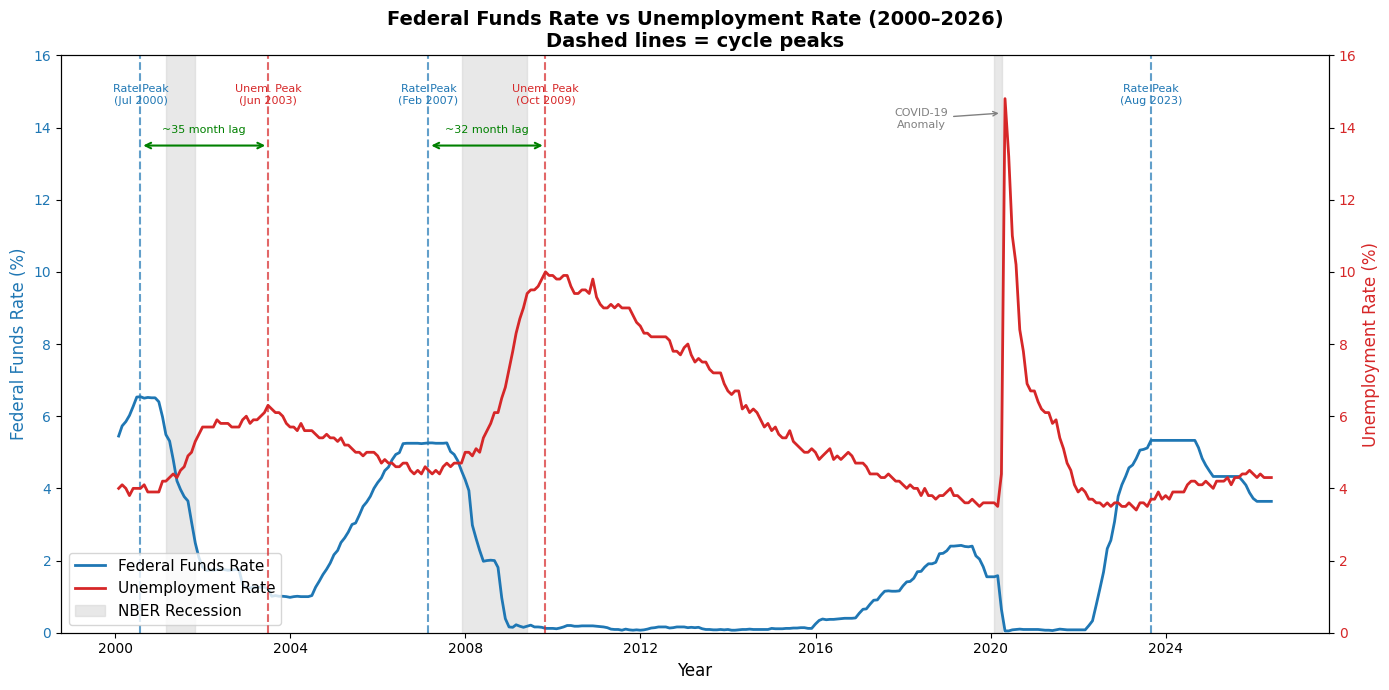

Rate peak cycle 1:         Jul 2000
Rate peak cycle 2:         Feb 2007
Rate peak cycle 3:         Aug 2023
Unemployment peak cycle 1: Jun 2003
Unemployment peak cycle 2: Oct 2009


In [47]:
plot_a1()

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task.
Use no more than 150 words and indicate the word count of your description below.

**Description:** **Description:** The dual-axis line chart overlays the Federal Funds 
Rate (blue, left axis) and Unemployment Rate (red, right axis) from 
2000 to 2026, with grey bands marking NBER recessions. Green 
double-headed arrows show the measured lag between rate peaks and 
subsequent unemployment peaks. In cycle 1, the Fed Funds Rate peaked 
in July 2000 and unemployment peaked in June 2003, a lag of 35 months. 
In cycle 2, the rate peaked in February 2007 and unemployment peaked 
in October 2009, a lag of 32 months. Both cycles confirm the 
hypothesis — unemployment consistently rises after rate peaks. The lag 
of 32–35 months is longer than originally estimated. The 2023 hiking 
cycle remains unfolding. The sharp COVID-19 spike in 2020 is annotated 
separately as a pandemic-driven anomaly unrelated to monetary tightening.

**Word count**: 120

### A.2

Restate your hypothesis/task below.

**Hypothesis/Task A.2:** The Treasury yield curve (10-year minus 2-year yield) has turned negative before every NBER-dated U.S. recession within 2000–2026. We test this by computing the spread, locating its sub-zero episodes, and comparing them against official recession start dates.

Place your visualizations below (max. 2). Make sure that everyting displays correctly in the GitHub file preview.

C:\Users\saaqi\AppData\Local\Temp\ipykernel_9912\1787305862.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


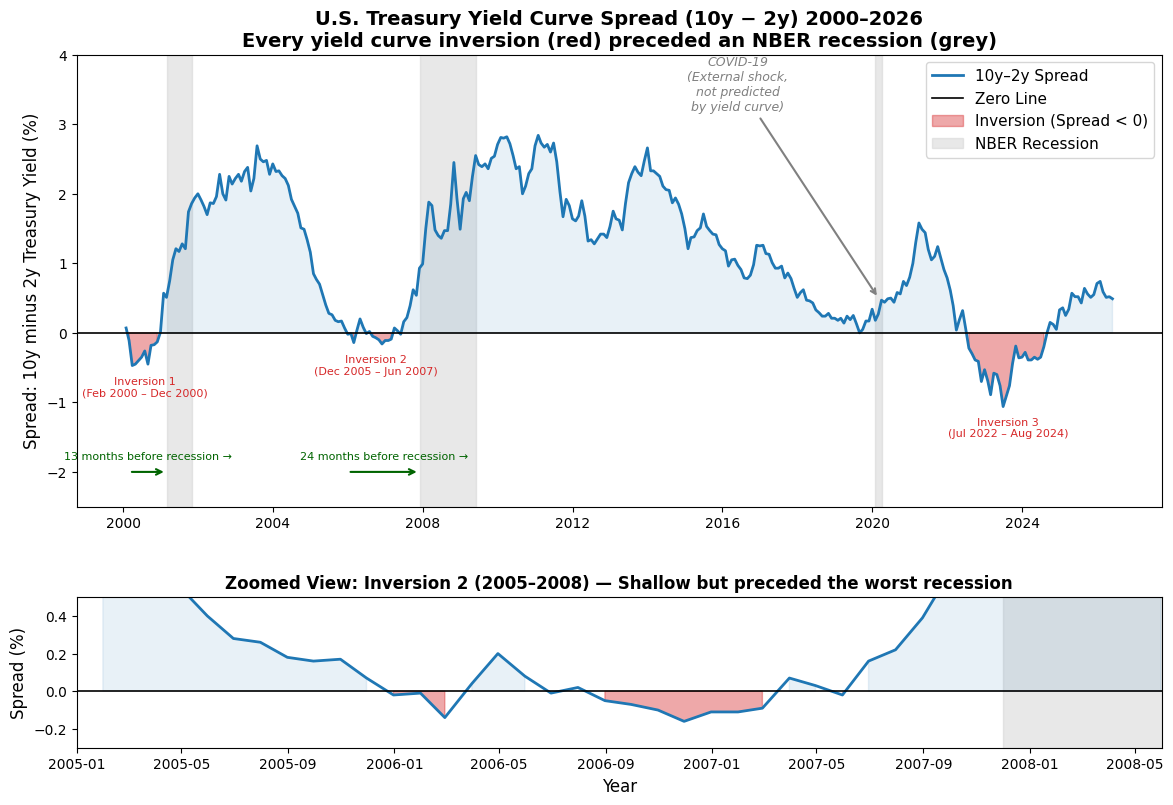

Chart saved as a2_yield_curve_spread.png


In [51]:
plot_a2()

Describe your visualizations and findings. Be clear which chart(s) you are referring to and relate your findings to the hypothesis/task. Use no more than 150 words and indicate the word count of your description below.

**Description:** The main chart plots the 10y–2y Treasury yield spread from 2000 to 2026 with red shading marking inversions and grey bands marking NBER recessions. Three inversions were identified: Inversion 1 (Feb–Dec 2000) preceded the 2001 recession by 13 months, Inversion 2 (Dec 2005–Jun 2007) preceded the 2008 recession by 24 months, and Inversion 3 (Jul 2022–Aug 2024) was the deepest at −1.0% with its outcome unfolding. The zoomed panel confirms Inversion 2 was very shallow yet preceded the worst recession. The 2020 COVID recession was not preceded by an inversion because it was an external pandemic shock, not a monetary-cycle downturn. Excluding this anomaly, the hypothesis is confirmed: every economic-cycle recession was preceded by yield curve inversion.

**Word count:** 118